# Marketplace seller Performance Analytics

This project analyszes seller performance using the Olist Brazilian E-commerce dataset. The goal is to analyze marketplace trends, seller performance, delivery behavior and customer purchasing patterns.

In [54]:
import pandas as pd
import numpy as np

In [55]:
orders = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv")
order_items = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv")
customers = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv")
sellers = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv")
payments = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv")
products = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv")

In [56]:
orders.head()
orders.shape
orders.info()
orders.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

### Data Cleaning
• Handling missing values  
• Filtering delivered orders  
• Fixing incorrect data types

In [57]:
products['product_category_name'] = products['product_category_name'].fillna("unknown")

products.fillna(products.median(numeric_only=True), inplace=True)

In [58]:
date_cols = [
'order_purchase_timestamp',
'order_approved_at',
'order_delivered_carrier_date',
'order_delivered_customer_date',
'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

### Data Aggregation

In [59]:
payments_agg = payments.groupby('order_id').agg({
    'payment_value':'sum',
    'payment_installments':'max'
}).reset_index()

In [60]:
df = orders.merge(customers, on="customer_id", how="left")
df = df.merge(order_items, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(sellers, on="seller_id", how="left")
df = df.merge(payments_agg, on="order_id", how="left")


#### Feature Engineering

In [61]:
df['delivery_delay'] = (
    df['order_delivered_customer_date'] -
    df['order_estimated_delivery_date']
).dt.days

In [62]:
df['late_delivery'] = (df['delivery_delay'] > 0).astype(int)

In [63]:
df[['order_delivered_customer_date','order_estimated_delivery_date','delivery_delay','late_delivery']].head()

,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay,late_delivery
0,2017-10-10 21:25:13,2017-10-18,-8.0,0
1,2018-08-07 15:27:45,2018-08-13,-6.0,0
2,2018-08-17 18:06:29,2018-09-04,-18.0,0
3,2017-12-02 00:28:42,2017-12-15,-13.0,0
4,2018-02-16 18:17:02,2018-02-26,-10.0,0


In [64]:
df['total_price'] = df['price'] + df['freight_value']

In [65]:
# Month column for GMV
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

In [66]:
# Delivery Duration
df['delivery_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.days

In [67]:
#Approval Time

df['approval_time'] = (
    df['order_approved_at'] -
    df['order_purchase_timestamp']
).dt.seconds / 3600

In [68]:
# Shipping Time
df['shipping_days'] = (
    df['order_delivered_carrier_date'] -
    df['order_purchase_timestamp']
).dt.days

In [69]:
# product size
df['product_volume'] = (
    df['product_length_cm'] *
    df['product_height_cm'] *
    df['product_width_cm']
)

### Customer Segmentation

In [70]:
#RFM features
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': 'max',
    'order_id': 'count',
    'total_price': 'sum'
}).reset_index()

rfm.columns = ['customer', 'last_purchase', 'frequency', 'monetary']

In [71]:
df = df.merge(rfm, left_on='customer_unique_id', right_on='customer')

### Business Queries

In [72]:
monthly_revenue = df.groupby('order_month')['total_price'].sum().reset_index()

monthly_revenue

,order_month,total_price
0,2016-09,354.75
1,2016-10,56808.84
2,2016-12,19.62
3,2017-01,137188.49
4,2017-02,286280.62
5,2017-03,432048.59
6,2017-04,412422.24
7,2017-05,586190.95
8,2017-06,502963.04
9,2017-07,584971.62


In [73]:
# Top Sellers
top_sellers = (
    df.groupby('seller_id')['total_price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_sellers

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    249640.70
7c67e1448b00f6e969d365cea6b010ab    239536.44
53243585a1d6dc2643021fd1853d8905    235856.68
4a3ca9315b744ce9f8e9374361493884    235539.96
fa1c13f2614d7b5c4749cbc52fecda94    204084.73
da8622b14eb17ae2831f4ac5b9dab84a    185192.32
7e93a43ef30c4f03f38b393420bc753a    182754.05
1025f0e2d44d7041d6cf58b6550e0bfa    172860.69
7a67c85e85bb2ce8582c35f2203ad736    162648.38
955fee9216a65b617aa5c0531780ce60    160602.68
Name: total_price, dtype: float64

In [74]:
# Cancellation rate
cancel_rate = (
    orders['order_status']
    .value_counts(normalize=True)
)

cancel_rate

order_status
delivered      0.970203
shipped        0.011132
canceled       0.006285
unavailable    0.006124
invoiced       0.003158
processing     0.003027
created        0.000050
approved       0.000020
Name: proportion, dtype: float64

In [75]:
repeat_customers = (
    df.groupby('customer_unique_id')['order_id']
    .nunique()
)

repeat_customers = repeat_customers[repeat_customers > 1].count()

repeat_customers

np.int64(2997)

## Predicting late delivery risk in an E-commerce Marketplace

Using marketplace order, seller, product, and logistics data, a machine learning model is build to predict whether an order will be delivered late.
This prediction helps:
* Identify high-risk deliveries
* Monitor seler logistics performance
* Help marketplace reduce delivery delays

In [76]:
model_df = df[
[
'price',
'freight_value',
'delivery_days',
'shipping_days',
'product_weight_g',
'product_volume',
'payment_installments',
'seller_state',
'late_delivery'
]
]

In [77]:
# missing values
model_df = model_df.fillna(model_df.median(numeric_only=True))

In [78]:
# Encoding categorical variables
model_df = pd.get_dummies(
    model_df,
    columns=['seller_state'],
    drop_first=True
)

In [79]:
X = model_df.drop('late_delivery', axis=1)
y = model_df['late_delivery']

In [80]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [81]:
# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [82]:
# using K-fold cross validation
from sklearn.model_selection import cross_val_score

In [83]:
# Logistic regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

scores = cross_val_score(
    log_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("Logistic Regression CV ROC-AUC:", scores.mean())

Logistic Regression CV ROC-AUC: 0.9545844515107126


In [84]:
# Using random forest with hyperparameter tuning

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [85]:
rf_params = {
'n_estimators':[100,200,300],
'max_depth':[8,10,12,None],
'min_samples_split':[2,5,10],
'min_samples_leaf':[1,2,4]
}

In [86]:
# randomized search

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

rf_search = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=20,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

In [87]:
print("Best RF Params:", rf_search.best_params_)

Best RF Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}


In [88]:
# Gradient Boosting with hyperparameter tuning
from sklearn.ensemble import GradientBoostingClassifier

gb_params = {
'n_estimators':[100,200],
'learning_rate':[0.01,0.05,0.1],
'max_depth':[3,4,5]
}


In [89]:
# Search

gb = GradientBoostingClassifier()

gb_search = RandomizedSearchCV(
    gb,
    gb_params,
    n_iter=10,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

best_gb = gb_search.best_estimator_

In [96]:
print("Best GB Params:", gb_search.best_params_)

Best GB Params: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1}


#### Ensemble Voting using soft voting mechanism

In [90]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ('log', log_model),
        ('rf', best_rf),
        ('gb', best_gb)
    ],
    voting='soft'
)

voting_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('log',
                              LogisticRegression(class_weight='balanced',
                                                 max_iter=1000)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     min_samples_leaf=2,
                                                     min_samples_split=5,
                                                     n_estimators=300,
                                                     random_state=42)),
                             ('gb',
                              GradientBoostingClassifier(max_depth=4,
                                                         n_estimators=200))],
                 voting='soft')

In [91]:
y_pred = voting_model.predict(X_test)

y_prob = voting_model.predict_proba(X_test)[:,1]

In [92]:
# Model evaluation

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98     21232
           1       0.68      0.78      0.73      1453

    accuracy                           0.96     22685
   macro avg       0.83      0.88      0.85     22685
weighted avg       0.97      0.96      0.96     22685

ROC-AUC: 0.9688168555456035


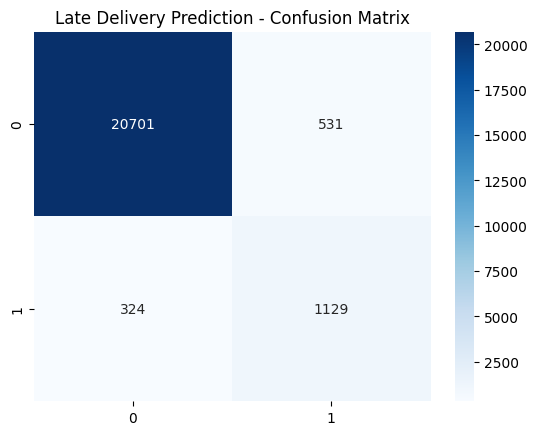

In [93]:
# Confusion metrics

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Late Delivery Prediction - Confusion Matrix")

plt.show()

In [95]:
# Feature importance using random forest

importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(10))

delivery_days           0.690128
freight_value           0.080359
shipping_days           0.066475
price                   0.045920
product_volume          0.044081
product_weight_g        0.040459
payment_installments    0.017111
seller_state_SP         0.005425
seller_state_MG         0.001957
seller_state_PR         0.001708
dtype: float64


## Interpretation

The results suggest that delivery delays are primarily influenced by logistics-related factors such as shipping time, freight cost, and package size. By monitoring these indicators, e-commerce platforms can identify high-risk shipments earlier and take proactive actions to reduce late deliveries.

The feature importance analysis also interprets that The most influential factor is delivery_days, contributing nearly 69% of the model's predictive power.

Other logistics-related variables such as freight cost, shipping time, and product dimensions also contribute to predicting late deliveries.

This suggests that logistics and shipment characteristics play a major role in delivery performance.

Accuracy      → 96%
ROC-AUC       → 0.97
Late recall   → 78%

### Preparing dataset for visualization

In [97]:
# Revenue metrics
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

In [98]:
# Seller Performance metrics
seller_metrics = df.groupby('seller_id').agg(
    total_revenue=('total_price','sum'),
    total_orders=('order_id','nunique'),
    avg_order_value=('total_price','mean'),
    avg_delivery_delay=('delivery_delay','mean')
).reset_index()

In [99]:
# Monthly revenue
monthly_revenue = df.groupby('order_month').agg(
    revenue=('total_price','sum'),
    orders=('order_id','nunique')
).reset_index()


In [100]:
# Customer Segmentation(RFM)
rfm['recency_days'] = (
    df['order_purchase_timestamp'].max() - rfm['last_purchase']
).dt.days

In [101]:
# Delivery delay distribution
delivery_stats = df[['delivery_delay']]

In [102]:
# Cancellation Analysis
cancel_stats = df.groupby(['seller_state','order_status']).size().reset_index(name='count')

In [103]:
# Exporting data for visualization
seller_metrics.to_csv("seller_metrics.csv", index=False)

monthly_revenue.to_csv("monthly_revenue.csv", index=False)

rfm.to_csv("customer_rfm.csv", index=False)

df.to_csv("marketplace_analytics.csv", index=False)